# 03 — VAE music generation

A fully connected variational autoencoder over whole songs. Each song is a sequence of MIDI pitches divided by 127, zero-padded to the longest song. The architecture and training settings are the original project's:

- Linear encoder (256 units) → μ, log σ² (64-dim latent) → linear decoder → sigmoid.
- Loss: BCE plus KL divergence. Adam at 1e-3, batch size 32, 100 epochs.
- Generation decodes random latents into one minute of music at 120 BPM.

**Changes from the 2024 notebook** (the original is kept in `notebooks/original_2024/`):

| Change | Why |
|---|---|
| Data unzipped from the repo instead of read from Google Drive | No manual Drive setup |
| `midi_file.flat` → `.flatten()` | `.flat` is deprecated in music21 |
| Model trained on the GPU | The original ran on CPU |
| Generated music saved as `.mid` and `.wav` | The original only played it inline and never saved it |
| **Masked accuracy** reported next to the original accuracy | The original accuracy counts padding zeros, so it looks high even when the model learns little (see RESULTS.md) |
| Novelty, diversity and FAD proxy added | Same definitions as the GAN evaluation |

**Runtime.** Parsing the MIDI files takes a few minutes the first time. Training takes about a minute on a T4.

**Running on Google Colab.** Upload this notebook, then choose *Runtime → Change runtime type → T4 GPU* and *Runtime → Run all*. The paths cell will ask you to upload `data/pokemon_midis.zip` from the repo. The generated music is saved as `.mid`, rendered to `.wav` and played inline. The last cell downloads every output as one zip. Unzip it into the repo's `results/` folder to keep the outputs.

**Running locally.** Run `pip install -r requirements.txt`, then open this notebook from the repo's `notebooks/` folder. WAV rendering needs [FluidSynth](https://www.fluidsynth.org/) and a General MIDI soundfont. Without them the notebook still saves the `.mid` files.

## 1. Setup

In [ ]:
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "music21"], check=True)
    # FluidSynth + a General MIDI soundfont render the generated .mid files to playable .wav audio
    subprocess.run("apt-get update -qq && apt-get install -y -qq fluidsynth fluid-soundfont-gm > /dev/null",
                   shell=True, check=True)

In [ ]:
import json
import pickle
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import music21
import music21.instrument
import music21.note
import music21.stream
import music21.tempo
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from scipy.spatial.distance import euclidean
from sklearn.metrics import mean_squared_error
from IPython.display import Audio, display

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device)

PyTorch 2.11.0+cu128 | device: cuda


In [ ]:
# ---- Configuration (original values unless noted) -------------------------
HIDDEN_DIM = 256
LATENT_DIM = 64
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
MAX_MIDI_VALUE = 127

BEATS_PER_MINUTE = 120      # generation: 1 minute of quarter-length-0.25 notes
NOTE_DURATION = 0.25
TARGET_SECONDS = 60
N_GEN_SAMPLES = 10          # new: sequences generated for novelty / diversity / FAD
METRIC_LENGTH = 100         # new: first 100 positions are compared

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- Paths: locally, find the repo from notebooks/ or the repo root; on Colab, upload the dataset
def find_repo_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data" / "pokemon_midis.zip").exists():
            return p
    return None


REPO_ROOT = find_repo_root()
if REPO_ROOT is None:
    if not IN_COLAB:
        raise FileNotFoundError("data/pokemon_midis.zip not found - run this notebook from inside the repo.")
    from google.colab import files
    REPO_ROOT = Path("/content/symphony-of-algorithms")
    (REPO_ROOT / "data").mkdir(parents=True, exist_ok=True)
    print("Select data/pokemon_midis.zip from the repo:")
    uploaded = files.upload()
    (REPO_ROOT / "data" / "pokemon_midis.zip").write_bytes(next(iter(uploaded.values())))

DATA_ZIP = REPO_ROOT / "data" / "pokemon_midis.zip"
MIDI_DIR = REPO_ROOT / "data" / "Pokemon MIDIs"
if not MIDI_DIR.exists():
    with zipfile.ZipFile(DATA_ZIP) as zf:
        zf.extractall(DATA_ZIP.parent)

AUDIO_DIR = REPO_ROOT / "results" / "audio"
WEIGHTS_DIR = REPO_ROOT / "Weights"
for d in (AUDIO_DIR, WEIGHTS_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"{len(list(MIDI_DIR.glob('*.mid')))} MIDI files in {MIDI_DIR.relative_to(REPO_ROOT)}")

FIG_DIR = REPO_ROOT / "results" / "figures" / "vae_reproduced"
FIG_DIR.mkdir(parents=True, exist_ok=True)

Select data/pokemon_midis.zip from the repo:


Saving pokemon_midis.zip to pokemon_midis.zip
307 MIDI files in data/Pokemon MIDIs


In [ ]:
SOUNDFONT = Path("/usr/share/sounds/sf2/FluidR3_GM.sf2")


def midi_to_wav(midi_path):
    # Render a .mid file to .wav with FluidSynth (installed automatically on Colab)
    if shutil.which("fluidsynth") is None or not SOUNDFONT.exists():
        print("FluidSynth or the soundfont is not installed - skipping WAV rendering (the .mid file is saved).")
        return None
    wav_path = midi_path.with_suffix(".wav")
    subprocess.run(["fluidsynth", "-ni", "-F", str(wav_path), "-r", "44100", str(SOUNDFONT), str(midi_path)],
                   check=True, capture_output=True)
    return wav_path


def save_and_play(midi_path):
    wav_path = midi_to_wav(midi_path)
    print(f"Saved {midi_path.relative_to(REPO_ROOT)}" + (f" and {wav_path.relative_to(REPO_ROOT)}" if wav_path else ""))
    if wav_path:
        display(Audio(str(wav_path)))

# Same definitions as the GAN evaluation in the original project (results/figures/gan/*.png)
def novelty_metric(generated_sequences, real_sequences):
    distances = []
    for gen_seq in generated_sequences:
        gen_seq_flat = gen_seq.flatten()
        real_distances = [euclidean(gen_seq_flat, real_seq.flatten()) for real_seq in real_sequences]
        distances.append(np.mean(real_distances))
    return np.mean(distances)


def nearest_neighbour_novelty(generated_sequences, real_sequences):
    # The definition RESULTS.md describes: distance to the *closest* real sequence
    return np.mean([min(euclidean(g.flatten(), r.flatten()) for r in real_sequences)
                    for g in generated_sequences])


def diversity_metric(sequences):
    n = len(sequences)
    distances = []
    for i in range(n):
        for j in range(i + 1, n):
            distances.append(euclidean(sequences[i].flatten(), sequences[j].flatten()))
    return np.mean(distances)


def fad_metric(generated_sequences, real_sequences):
    gen_means = np.mean(generated_sequences, axis=0)
    gen_vars = np.var(generated_sequences, axis=0)
    real_means = np.mean(real_sequences, axis=0)
    real_vars = np.var(real_sequences, axis=0)
    mean_diff = mean_squared_error(gen_means.flatten(), real_means.flatten())
    var_diff = mean_squared_error(gen_vars.flatten(), real_vars.flatten())
    return mean_diff + var_diff


def generation_metrics(generated_sequences, real_sequences):
    return {
        "novelty (mean distance, as in original code)": float(novelty_metric(generated_sequences, real_sequences)),
        "novelty (nearest neighbour, as in RESULTS.md)": float(nearest_neighbour_novelty(generated_sequences, real_sequences)),
        "diversity": float(diversity_metric(generated_sequences)),
        "FAD proxy": float(fad_metric(generated_sequences, real_sequences)),
    }

## 2. Load the Pokémon MIDI dataset

In [ ]:
NOTES_CACHE = REPO_ROOT / "data" / "notes_vae.pkl"


def load_midi_files(midi_folder):
    # One sequence of MIDI pitch numbers per file (single notes only, as in the original)
    midi_data = []
    for path in sorted(midi_folder.glob("*.mid")):
        try:
            midi_file = music21.converter.parse(path)
        except Exception as e:  # a few fan transcriptions are malformed
            print(f"  skipped {path.name}: {e!r}")
            continue
        notes = [int(el.pitch.midi) for el in midi_file.flatten().notes if isinstance(el, music21.note.Note)]
        if notes:
            midi_data.append(notes)
    return midi_data


if NOTES_CACHE.exists():
    midi_data = pickle.loads(NOTES_CACHE.read_bytes())
else:
    print("Parsing MIDI files with music21 (a few minutes; cached afterwards)...")
    midi_data = load_midi_files(MIDI_DIR)
    NOTES_CACHE.write_bytes(pickle.dumps(midi_data))

lengths = np.array([len(s) for s in midi_data])
print(f"{len(midi_data)} songs | notes per song: median {np.median(lengths):.0f}, max {lengths.max()}")
print(f"Share of the padded input that is padding: {1 - lengths.sum() / (len(lengths) * lengths.max()):.1%}")

Parsing MIDI files with music21 (a few minutes; cached afterwards)...


/usr/local/lib/python3.13/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=6, data=b'Pok\xe9mon: Elite Four (Piano)'>; getting generic Instrument
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/music21/midi/translate.py:922: TranslateWarning: Unable to determine instrument from <music21.midi.MidiEvent SEQUENCE_TRACK_NAME, track=0, data=b'Pok\xe9mon Gym'>; getting generic Instrument
  warnings.warn(


304 songs | notes per song: median 248, max 1604
Share of the padded input that is padding: 80.6%


In [ ]:
# Normalize MIDI values to the range [0, 1]
midi_data_normalized = [np.array(seq) / MAX_MIDI_VALUE for seq in midi_data]


class MidiDataset(Dataset):
    def __init__(self, midi_data):
        self.data = midi_data
        self.max_length = max(len(seq) for seq in midi_data)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sequence = self.data[idx]
        padded_sequence = np.pad(sequence, (0, self.max_length - len(sequence)), "constant", constant_values=0)
        return torch.tensor(padded_sequence, dtype=torch.float32), len(sequence)


dataset = MidiDataset(midi_data_normalized)
data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

## 3. Model

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim * 2),   # mean and log variance
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid(),                            # output in [0, 1]
        )

    def encode(self, x):
        hidden = self.encoder(x)
        return hidden[:, :self.latent_dim], hidden[:, self.latent_dim:]

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var


def loss_function(recon_x, x, mu, log_var):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction="sum")
    KL = 0.5 * torch.sum(torch.exp(log_var) + mu.pow(2) - 1 - log_var)
    return BCE + KL, BCE, KL


def compute_accuracy(recon_x, x, threshold=0.5):
    # Original metric: agreement after thresholding, over every position (padding included)
    return ((recon_x > threshold) == (x > threshold)).float().mean()


def compute_masked_accuracy(recon_x, x, lengths, threshold=0.5):
    # New: the same agreement, counted only over real (non-padding) notes
    positions = torch.arange(x.shape[1], device=x.device)[None, :]
    mask = positions < lengths[:, None]
    agree = (recon_x > threshold) == (x > threshold)
    return agree[mask].float().mean()


model = VAE(dataset.max_length, HIDDEN_DIM, LATENT_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=1604, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=1604, bias=True)
    (3): Sigmoid()
  )
)


## 4. Train

In [ ]:
history = {"total_loss": [], "recon_loss": [], "kl_loss": [], "accuracy": [], "masked_accuracy": []}

for epoch in range(NUM_EPOCHS):
    model.train()
    sums = {k: 0.0 for k in history}
    num_batches = 0
    for batch, lengths_batch in data_loader:
        batch, lengths_batch = batch.to(device), lengths_batch.to(device)
        optimizer.zero_grad()
        recon_batch, mu, log_var = model(batch)
        loss, recon_loss, kl_loss = loss_function(recon_batch, batch, mu, log_var)
        loss.backward()
        optimizer.step()

        sums["total_loss"] += loss.item()
        sums["recon_loss"] += recon_loss.item()
        sums["kl_loss"] += kl_loss.item()
        sums["accuracy"] += compute_accuracy(recon_batch, batch).item()
        sums["masked_accuracy"] += compute_masked_accuracy(recon_batch, batch, lengths_batch).item()
        num_batches += 1

    for k in history:
        history[k].append(sums[k] / num_batches)

    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"Total Loss: {history['total_loss'][-1]:.4f}")
    print(f"Reconstruction Loss: {history['recon_loss'][-1]:.4f}")
    print(f"KL Divergence Loss: {history['kl_loss'][-1]:.4f}")
    print(f"Accuracy: {history['accuracy'][-1]:.4f} | Masked accuracy (real notes only): {history['masked_accuracy'][-1]:.4f}")
    print("-" * 50)

pd.DataFrame(history).to_csv(FIG_DIR / "epochs_metrics.csv", index_label="epoch")
torch.save(model.state_dict(), WEIGHTS_DIR / "vae.pt")

Epoch 1/100
Total Loss: 28448.9607
Reconstruction Loss: 28246.5141
KL Divergence Loss: 202.4468
Accuracy: 0.7714 | Masked accuracy (real notes only): 0.5460
--------------------------------------------------
Epoch 2/100
Total Loss: 15591.5477
Reconstruction Loss: 14122.1444
KL Divergence Loss: 1469.4031
Accuracy: 0.9117 | Masked accuracy (real notes only): 0.5583
--------------------------------------------------
Epoch 3/100
Total Loss: 10947.3007
Reconstruction Loss: 10069.7314
KL Divergence Loss: 877.5692
Accuracy: 0.9112 | Masked accuracy (real notes only): 0.5644
--------------------------------------------------
Epoch 4/100
Total Loss: 9960.8505
Reconstruction Loss: 9164.7347
KL Divergence Loss: 796.1159
Accuracy: 0.9158 | Masked accuracy (real notes only): 0.5724
--------------------------------------------------
Epoch 5/100
Total Loss: 9574.3587
Reconstruction Loss: 9076.2287
KL Divergence Loss: 498.1299
Accuracy: 0.9182 | Masked accuracy (real notes only): 0.5782
--------------

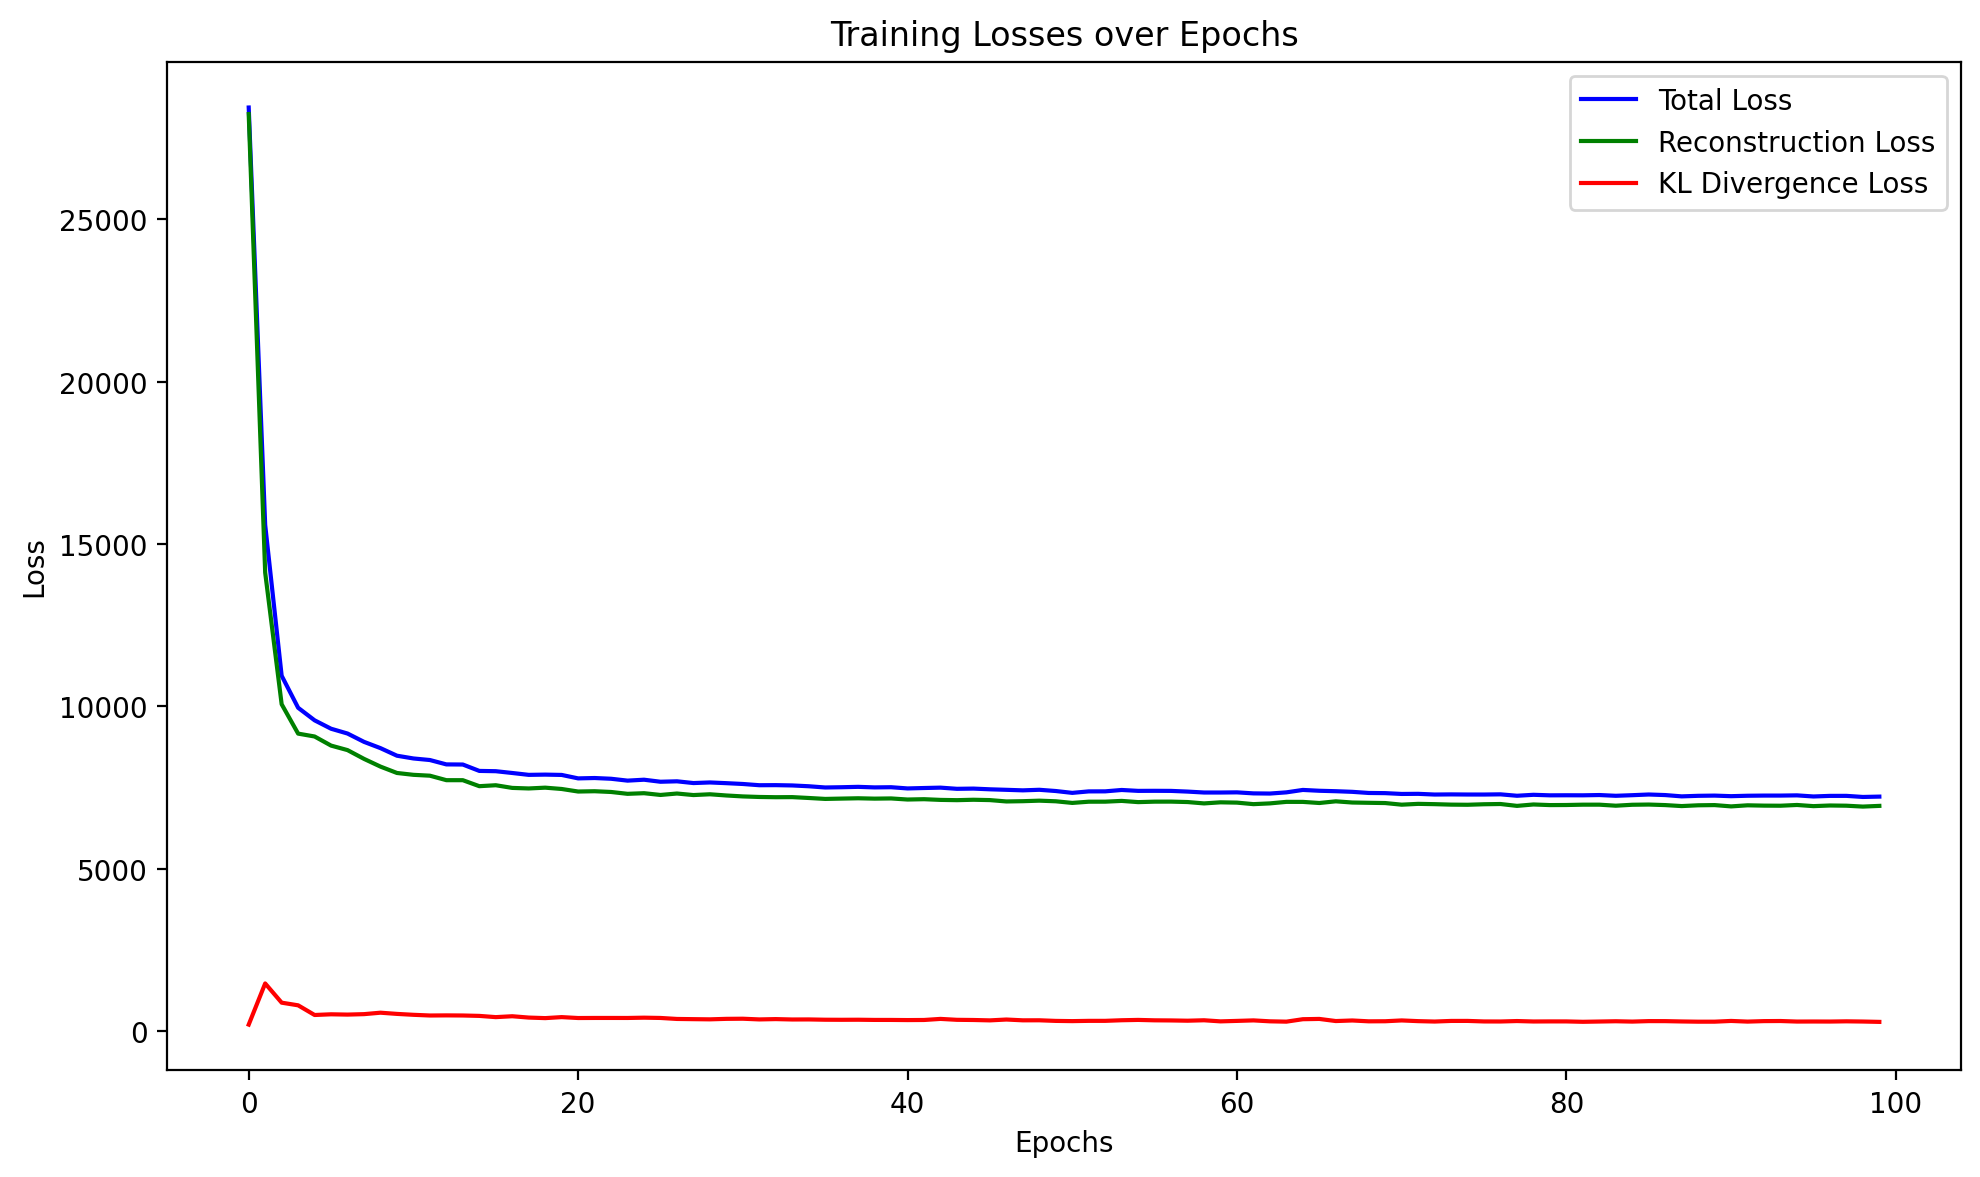

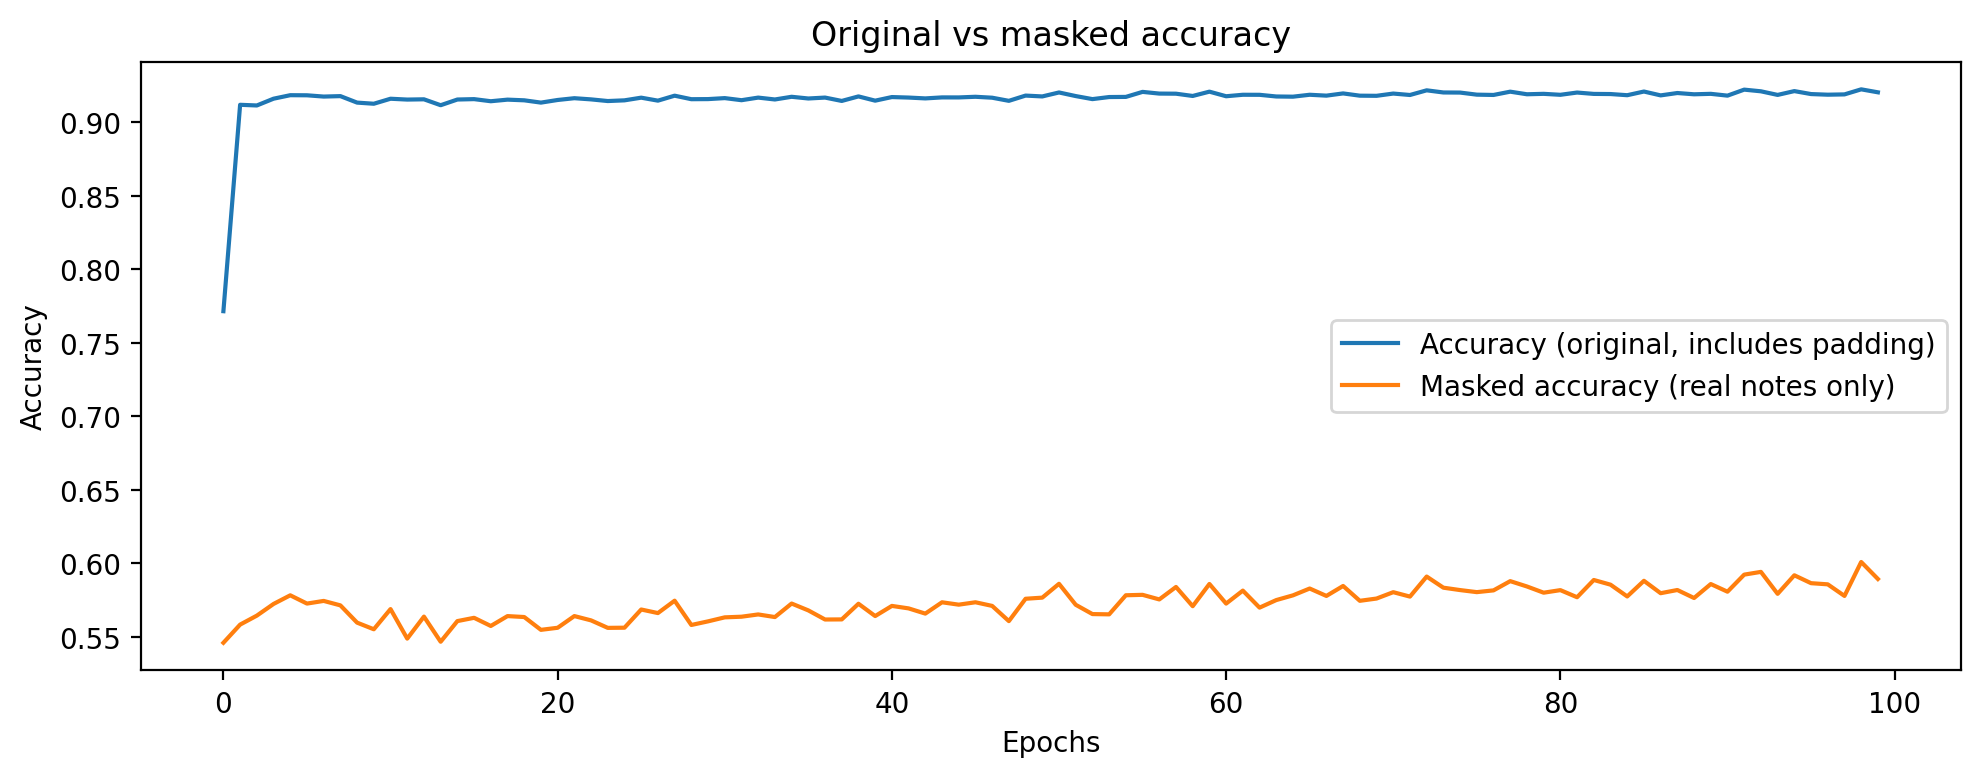

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history["total_loss"], label="Total Loss", color="blue")
plt.plot(history["recon_loss"], label="Reconstruction Loss", color="green")
plt.plot(history["kl_loss"], label="KL Divergence Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Losses over Epochs")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "training_losses_recon_vs_kl.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history["accuracy"], label="Accuracy (original, includes padding)")
plt.plot(history["masked_accuracy"], label="Masked accuracy (real notes only)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Original vs masked accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "accuracy_vs_masked_accuracy.png", dpi=150)
plt.show()

## 5. Generate one minute of music

In [ ]:
model.eval()
with torch.no_grad():
    generated = model.decode(torch.randn(N_GEN_SAMPLES, LATENT_DIM, device=device)).cpu().numpy()

total_beats = (BEATS_PER_MINUTE / 60) * TARGET_SECONDS
num_notes = int(total_beats // NOTE_DURATION)
generated_music = generated[0, :num_notes]

music_stream = music21.stream.Stream()
music_stream.insert(0, music21.tempo.MetronomeMark(number=BEATS_PER_MINUTE))
music_stream.insert(0, music21.instrument.Piano())
for pitch in generated_music:
    if pitch > 0:  # only include notes that have a valid pitch
        new_note = music21.note.Note(int(pitch * MAX_MIDI_VALUE))
        new_note.quarterLength = NOTE_DURATION
        music_stream.append(new_note)

midi_path = AUDIO_DIR / "vae_generated.mid"
music_stream.write("midi", fp=str(midi_path))
save_and_play(midi_path)
generated_pitches = (generated_music * MAX_MIDI_VALUE).astype(int)
print(f"{len(generated_music)} notes | distinct pitches: {len(set(generated_pitches))} | "
      f"range MIDI {generated_pitches.min()}-{generated_pitches.max()}")

Saved results/audio/vae_generated.mid and results/audio/vae_generated.wav


[Audio player removed to keep this notebook small enough for GitHub. The generated .wav and .mid files are in the repo's results/ folder.]


480 notes | distinct pitches: 56 | range MIDI 3-62


## 6. Metrics

Novelty, diversity and FAD proxy compare the first 100 generated positions with the first 100 notes of every song that has at least 100 notes. Both are normalised pitch (÷ 127), the representation the VAE reads.

In [ ]:
real_sequences = np.array([seq[:METRIC_LENGTH] for seq in midi_data_normalized if len(seq) >= METRIC_LENGTH])
generated_sequences = generated[:, :METRIC_LENGTH]

metrics = {
    "total_loss": history["total_loss"][-1],
    "reconstruction_loss": history["recon_loss"][-1],
    "kl_loss": history["kl_loss"][-1],
    "accuracy (original, includes padding)": history["accuracy"][-1],
    "masked accuracy (real notes only)": history["masked_accuracy"][-1],
    **generation_metrics(generated_sequences, real_sequences),
}
original_vae = {"total_loss": 7009.2905, "reconstruction_loss": 6746.8640, "kl_loss": 262.4265,
                "accuracy (original, includes padding)": 0.9243,
                "novelty (mean distance, as in original code)": 0.012}
display(pd.DataFrame({"Original (2024)": original_vae, "This run": metrics}))

(REPO_ROOT / "results" / "vae_reproduced_metrics.json").write_text(
    json.dumps({"metrics": metrics, "history": history}, indent=2))

,Original (2024),This run
total_loss,7009.2905,7224.539844
reconstruction_loss,6746.8640,6938.755737
kl_loss,262.4265,285.784120
"accuracy (original, includes padding)",0.9243,0.920176
"novelty (mean distance, as in original code)",0.0120,1.383312
masked accuracy (real notes only),NaN,0.589331
"novelty (nearest neighbour, as in RESULTS.md)",NaN,0.571806
diversity,NaN,0.831648
FAD proxy,NaN,0.004655


13203

**Reading the numbers.** If the original accuracy is high but the masked accuracy is much lower, most of the "accuracy" comes from correctly reproducing padding zeros. The model has learned little about the actual notes. This is the problem RESULTS.md suspected from the flat loss curve. Summed losses scale with the padded length, so they are only comparable to the original if the maximum song length is the same.

In [ ]:
# On Colab, download everything this notebook produced (figures, audio, metrics) as one zip.
# Unzip it into the repo's results/ folder to keep the outputs.
if IN_COLAB:
    from google.colab import files
    archive = shutil.make_archive("/content/vae_results", "zip", REPO_ROOT / "results")
    files.download(archive)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>